In [1]:
from pathlib import Path

import polars as pl

In [3]:
root_dir = Path().resolve().parent
path = root_dir / "data" / "tokyo_23_mesh_master_multi_30min.csv"

df = pl.read_csv(path)
df.head()

mesh_id,latitude,longitude,city_name,district_name,station_name,distance_m,walk_minutes
str,f64,f64,str,str,str,f64,f64
"""35.530901_139.807841""",35.530901,139.807841,"""大田区""","""""","""新整備場""",2318.5,29.0
"""35.531802_139.808940""",35.531802,139.80894,"""大田区""","""""","""新整備場""",2347.3,29.3
"""35.532703_139.793555""",35.532703,139.793555,"""大田区""","""""","""新整備場""",1276.7,16.0
"""35.532703_139.793555""",35.532703,139.793555,"""大田区""","""""","""羽田空港第1ターミナル""",1999.7,25.0
"""35.532703_139.793555""",35.532703,139.793555,"""大田区""","""""","""羽田空港第1・第2ターミナル""",2022.4,25.3


In [5]:
df.group_by(["mesh_id", "city_name"]).agg(pl.col("station_name").n_unique().alias("unique_station_count")).sort(
    "unique_station_count", descending=True
).head(10)

mesh_id,city_name,unique_station_count
str,str,u32
"""35.689459_139.761687""","""千代田区""",54
"""35.688558_139.762786""","""千代田区""",54
"""35.684955_139.760588""","""千代田区""",53
"""35.688558_139.761687""","""千代田区""",53
"""35.689459_139.762786""","""千代田区""",53
"""35.684054_139.760588""","""千代田区""",53
"""35.689459_139.760588""","""千代田区""",53
"""35.684054_139.759489""","""千代田区""",52
"""35.690360_139.761687""","""千代田区""",52


In [20]:
df.group_by("city_name").agg(pl.count()).sort("count")

/var/folders/b_/d26mn34d48sgn3jjzzwcqyz00000gn/T/ipykernel_86940/3924051337.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  df.group_by("city_name").agg(pl.count()).sort("count")


city_name,count
str,u32
"""江戸川区""",16
"""江東区""",301
"""台東区""",1013
"""荒川区""",1022
"""中央区""",1027
…,…
"""葛飾区""",3512
"""練馬区""",4845
"""足立区""",5365


In [21]:
import geopandas as gpd
import pydeck as pdk

TOKYO_23KU_CODES = [
    "13101",  # 千代田区
    "13102",  # 中央区
    "13103",  # 港区
    "13104",  # 新宿区
    "13105",  # 文京区
    "13106",  # 台東区
    "13107",  # 墨田区
    "13108",  # 江東区
    "13109",  # 品川区
    "13110",  # 目黒区
    "13111",  # 大田区
    "13112",  # 世田谷区
    "13113",  # 渋谷区
    "13114",  # 中野区
    "13115",  # 杉並区
    "13116",  # 豊島区
    "13117",  # 北区
    "13118",  # 荒川区
    "13119",  # 板橋区
    "13120",  # 練馬区
    "13121",  # 足立区
    "13122",  # 葛飾区
    "13123",  # 江戸川区
]
boundary_geojson_dir = root_dir / "data" / "boundary"

In [31]:
gdfs: list[gpd.GeoDataFrame] = []

for ward_code in TOKYO_23KU_CODES:
    geojson_path = boundary_geojson_dir / f"{ward_code}.json"

    # GeoJSONを読み込み
    gdf = gpd.read_file(geojson_path)

    # CRS（座標参照系）を設定（WGS84）
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    gdfs.append(gdf)

if not gdfs:
    raise FileNotFoundError("東京23区のGeoJSONファイルが1つも見つかりませんでした")

# 全区のGeoDataFrameを統合
combined_gdf = gpd.pd.concat(gdfs, ignore_index=True)
combined_gdf["name"] = combined_gdf["name"].str.replace("東京都", "")

In [33]:
combined_gdf.head(1)

,name,geometry
0,千代田区,"POLYGON ((139.77287 35.7037, 139.77279 35.7031..."


In [27]:
ward = combined_gdf.loc[combined_gdf["name"] == "東京都江東区"]
for row in ward.itertuples():
    print(row.geometry)

POLYGON ((139.79993936361097 35.59522974765491, 139.79447687430843 35.59218225190955, 139.7942125545659 35.59233898215848, 139.79342997441393 35.59280301794507, 139.7939038002204 35.59306030588857, 139.79456839201782 35.593421170550755, 139.79499250330161 35.59365169377082, 139.7954185598188 35.593883467947876, 139.79582603094673 35.5941051706173, 139.79584213960322 35.59411391922214, 139.7960724119124 35.59423919838048, 139.79633841788382 35.59438483818991, 139.7970014790352 35.59474752307989, 139.79746350213907 35.59500024336671, 139.79758758789706 35.595068108006956, 139.79850843071972 35.595564999625196, 139.79859172502825 35.59560994594244, 139.79861041473907 35.595619928417136, 139.79913955874383 35.59590253227623, 139.79948268517796 35.596088117272984, 139.8000000003999 35.59637010779443, 139.80147105114827 35.59717113484015, 139.80225269780397 35.59759262190215, 139.8037777303581 35.5984199280374, 139.8044258366832 35.59763961327769, 139.8000000003999 35.595262323797385, 139.79

In [23]:
combined_gdf.loc[combined_gdf["N03_004"] == "江戸川区"].iloc[0]["geometry"]

KeyError: 'N03_004'

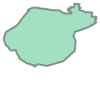

In [13]:
combined_gdf.iloc[0]["geometry"]

In [ ]:
map_provider = "carto"
map_style = "https://basemaps.cartocdn.com/gl/voyager-gl-style/style.json"
api_keys = None

# =============================================================================
# レイヤー構成
# =============================================================================
layers = []

# 境界レイヤー
boundary_layer = pdk.Layer(
    "GeoJsonLayer",
    data=boundary_geojson,
    get_line_color=[180, 180, 200, 200],
    get_fill_color=[0, 0, 0, 0],
    line_width_min_pixels=2,
    pickable=False,
)
layers.append(boundary_layer)

# デッキ作成
deck = pdk.Deck(
    map_provider=map_provider,
    layers=layers,
    # initial_view_state=view_state,
    map_style=map_style,
    api_keys=api_keys,
)
deck

{
  "initialViewState": {
    "latitude": 0,
    "longitude": 0,
    "zoom": 1
  },
  "layers": [
    {
      "@@type": "GeoJsonLayer",
      "data": {},
      "getFillColor": [
        0,
        0,
        0,
        0
      ],
      "getLineColor": [
        180,
        180,
        200,
        200
      ],
      "id": "7f844b9a-043d-47ec-9d06-1e3cf643fc09",
      "lineWidthMinPixels": 2,
      "pickable": false
    }
  ],
  "mapProvider": "carto",
  "mapStyle": "https://basemaps.cartocdn.com/gl/voyager-gl-style/style.json",
  "views": [
    {
      "@@type": "MapView",
      "controller": true
    }
  ]
}